# Insurance Cost Prediction

## Import Libraries

In [1]:
# Import Libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

import joblib

## Load Dataset

In [2]:
# Load Dataset

df = pd.read_csv("insurance.csv")

In [3]:
print(df.head())

   age     sex     bmi  children smoker     region      charges
0   19  female  27.900         0    yes  southwest  16884.92400
1   18    male  33.770         1     no  southeast   1725.55230
2   28    male  33.000         3     no  southeast   4449.46200
3   33    male  22.705         0     no  northwest  21984.47061
4   32    male  28.880         0     no  northwest   3866.85520


## Data Understanding


In [4]:
# Data Understanding

print(df.shape)

(1338, 7)


In [5]:
print(df.info())

<class 'pandas.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   str    
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   str    
 5   region    1338 non-null   str    
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), str(3)
memory usage: 73.3 KB
None


In [6]:
print(df.describe())

               age          bmi     children       charges
count  1338.000000  1338.000000  1338.000000   1338.000000
mean     39.207025    30.663397     1.094918  13270.422265
std      14.049960     6.098187     1.205493  12110.011237
min      18.000000    15.960000     0.000000   1121.873900
25%      27.000000    26.296250     0.000000   4740.287150
50%      39.000000    30.400000     1.000000   9382.033000
75%      51.000000    34.693750     2.000000  16639.912515
max      64.000000    53.130000     5.000000  63770.428010


##  Data Cleaning

In [7]:
#  Data Cleaning

print(df.isnull().sum())

age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64


In [8]:
print(df.duplicated().sum())

1


In [9]:
duplicates = df.duplicated().sum()
print("Duplicate Rows:", duplicates)

if duplicates > 0:
    df.drop_duplicates(inplace=True)

Duplicate Rows: 1


In [10]:
print("Dataset Shape:", df.shape)

Dataset Shape: (1337, 7)


## Exploratory Data Analysis (EDA)

## Charges Distribution

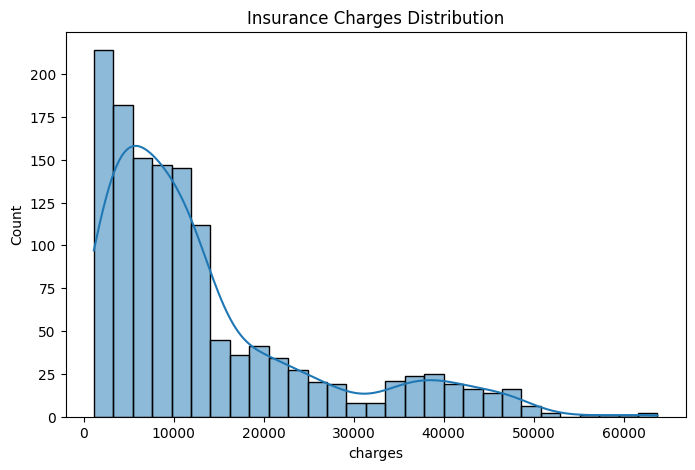

In [11]:
# EDA (Exploratory Data Analysis)

# Charges Distribution

plt.figure(figsize=(8,5))
sns.histplot(df["charges"], kde=True)
plt.title("Insurance Charges Distribution")
plt.show()


### Observation

The distribution of insurance charges is right-skewed. Most customers have relatively lower insurance charges, while a smaller number of customers have very high charges.

### Age Distribution

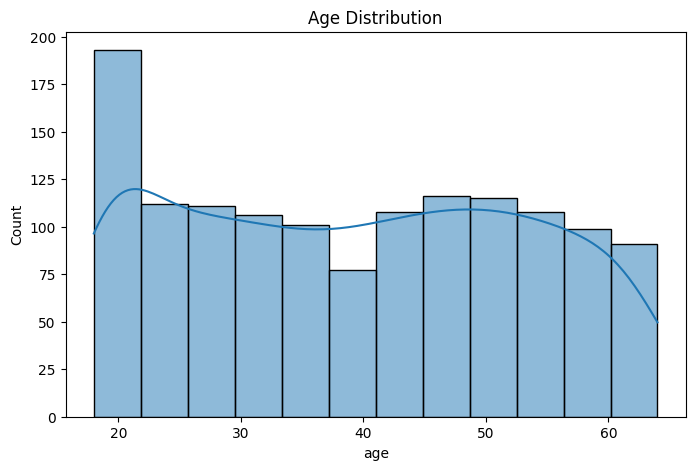

In [12]:
# Ages Distribution

plt.figure(figsize=(8,5))
sns.histplot(df["age"], kde=True)
plt.title("Age Distribution")
plt.show()

### Observation

The age distribution is fairly balanced across different age groups. Most individuals are between 18 and 65 years old, indicating that the dataset contains customers from a wide range of ages.

### Smoker Count

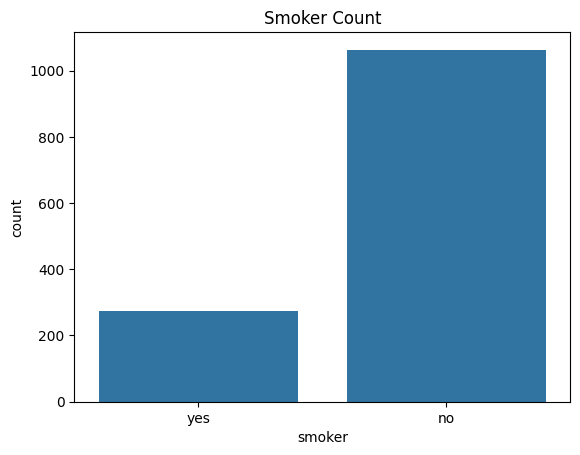

In [13]:
# Smoker Count

sns.countplot(x="smoker", data=df)
plt.title("Smoker Count")
plt.show()

### Observation

The number of non-smokers is significantly higher than the number of smokers in the dataset. This indicates that most customers do not smoke, while only a smaller portion are smokers.

### Gender Count

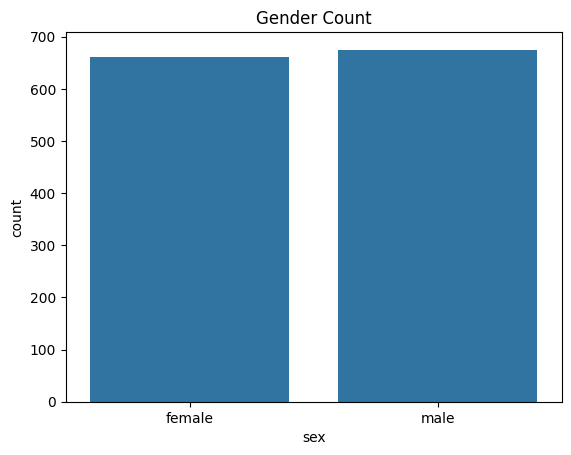

In [14]:
# Gender Count

sns.countplot(x="sex", data=df)
plt.title("Gender Count")
plt.show()

### Observation

The dataset contains a nearly equal number of male and female customers. This balanced distribution helps reduce gender bias during model training.

### BMI Count


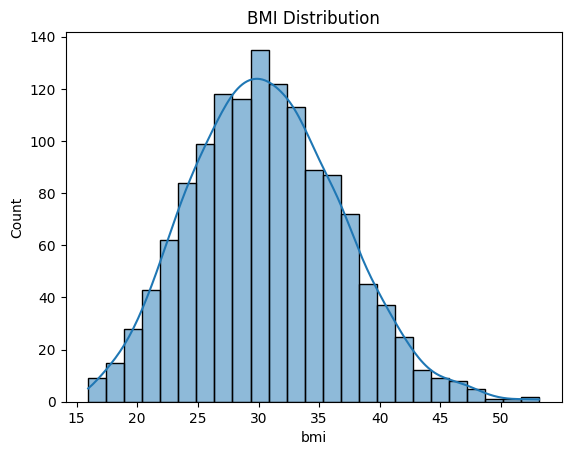

In [15]:
# BMI Count

sns.histplot(df["bmi"], kde=True)
plt.title("BMI Distribution")
plt.show()

### Observation

The BMI values are concentrated around the middle range, with most customers having a BMI between 25 and 35. A few customers have very high BMI values, which may contribute to higher insurance charges.

## Age vs Charges

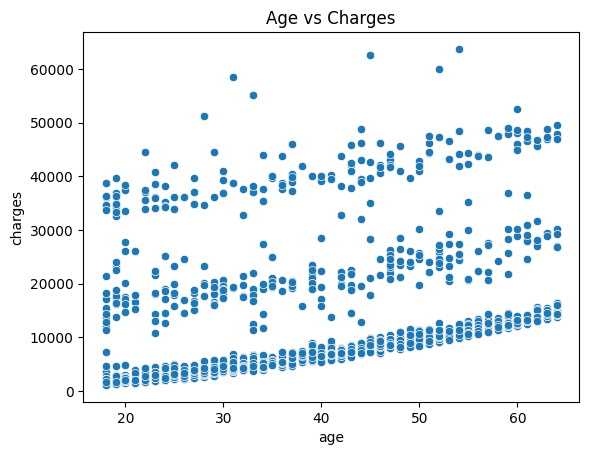

In [16]:
# Age vs Charges

sns.scatterplot(x="age", y="charges", data=df)
plt.title("Age vs Charges")
plt.show()

### Observation

Insurance charges generally increase with age. Older individuals tend to incur higher medical expenses, resulting in higher insurance charges.

## BMI vs Charges

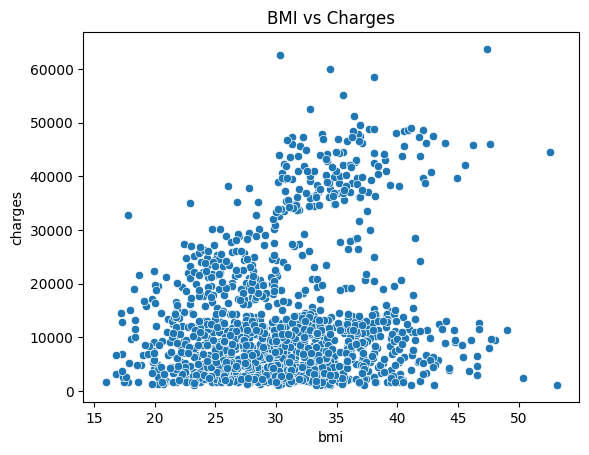

In [17]:
# BMI vs Charges

sns.scatterplot(x="bmi", y="charges", data=df)
plt.title("BMI vs Charges")
plt.show()

### Observation

Customers with higher BMI values tend to have higher insurance charges. This suggests that BMI has a positive influence on medical insurance costs.

## Smoker vs Charges

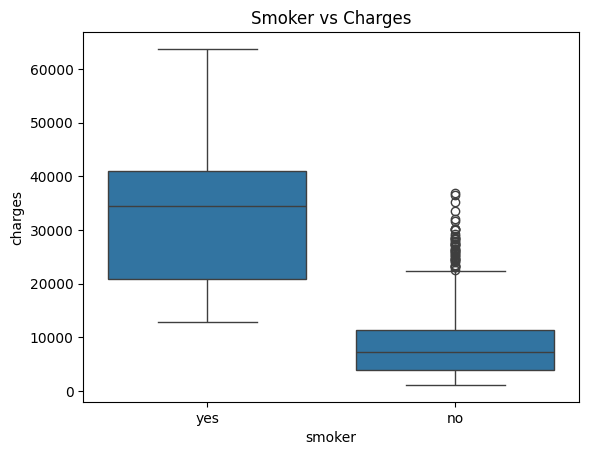

In [18]:
# Smoker vs Charges

sns.boxplot(x="smoker", y="charges", data=df)
plt.title("Smoker vs Charges")
plt.show()

### Observation

Smokers have significantly higher insurance charges compared to non-smokers. Smoking appears to be one of the strongest factors affecting insurance costs.

## Region vs Charges

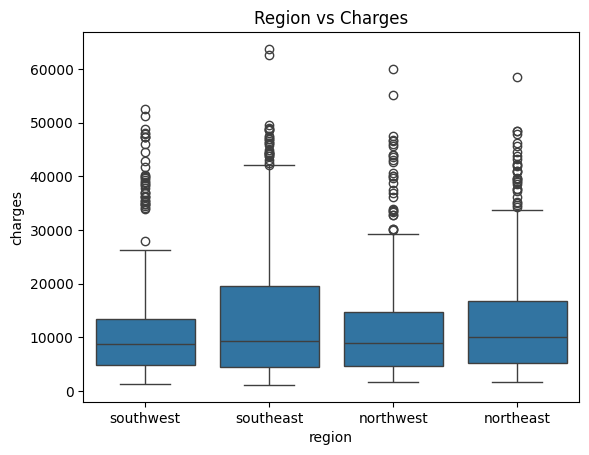

In [19]:
# Region vs Charges

sns.boxplot(x="region", y="charges", data=df)
plt.title("Region vs Charges")
plt.show()

### Observation

Insurance charges vary slightly across regions. However, regional differences are relatively small compared to the impact of smoking status, age, and BMI.

## Correlation Heatmap

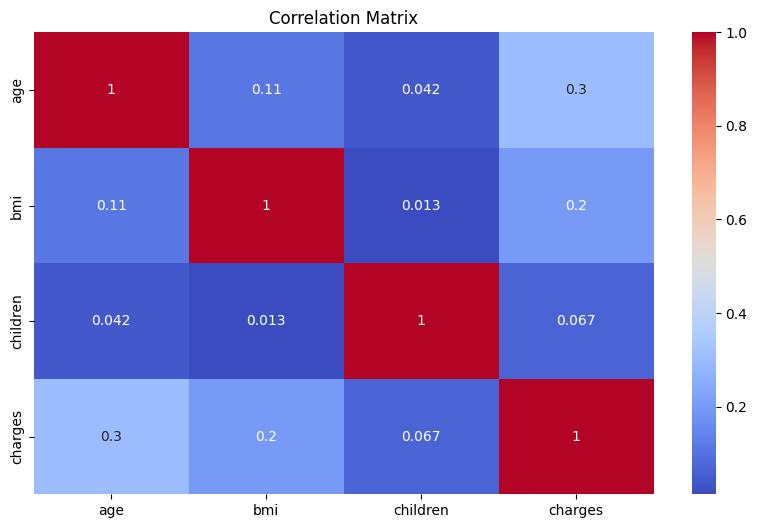

In [20]:
# Correlation Heatmap

plt.figure(figsize=(10,6))

sns.heatmap(
    df.corr(numeric_only=True),
    annot=True,
    cmap="coolwarm"
)

plt.title("Correlation Matrix")
plt.show()

### Observation

Age and BMI show positive correlations with insurance charges. Smoking status has the strongest relationship with charges, while children and region have comparatively weaker effects.

## Label Encoding

In [21]:
# Label Encoding

from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()

df["sex"] = le.fit_transform(df["sex"])
df["smoker"] = le.fit_transform(df["smoker"])
df["region"] = le.fit_transform(df["region"])

In [22]:
print(df.head())

   age  sex     bmi  children  smoker  region      charges
0   19    0  27.900         0       1       3  16884.92400
1   18    1  33.770         1       0       2   1725.55230
2   28    1  33.000         3       0       2   4449.46200
3   33    1  22.705         0       0       1  21984.47061
4   32    1  28.880         0       0       1   3866.85520


## Feature Selection

In [23]:
# Feature Selection

X = df.drop("charges", axis=1)
y = df["charges"]

##  Train-Test Split

In [24]:
# Train-Test Split

from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

##  Model Building

## Linear Regression

In [25]:
# Model Building

# Linear Regression

from sklearn.linear_model import LinearRegression
model = LinearRegression()
model.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](6,)","[ 248.76, -99.7 , 312.61, 534.12,23052.15, -237.63]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](6,)","['age','sex','bmi','children','smoker','region']"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,-1.105e+04
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,6
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int,6


In [26]:
# Model Evaluation

y_pred = model.predict(X_test)

## MAE

In [27]:
# MAE

mae = mean_absolute_error(y_test, y_pred)
print("MAE:", mae)

MAE: 4182.353155288297


## MSE

In [28]:
# MSE

mse = mean_squared_error(y_test, y_pred)
print("MSE:", mse)

MSE: 35493102.61165053


## RMSE

In [29]:
# RMSE

rmse = np.sqrt(mean_squared_error(y_test, y_pred))
print("RMSE:", rmse)

RMSE: 5957.60879981646


## R2 Score

In [30]:
# R2 Score

from sklearn.metrics import r2_score
r2 = r2_score(y_test, y_pred)
print("R2 Score:", r2)

R2 Score: 0.8068466322629111


In [31]:
from sklearn.metrics import r2_score

lr_r2 = r2_score(y_test, y_pred)

print("Linear Regression R2 Score:", lr_r2)

Linear Regression R2 Score: 0.8068466322629111


## Decision Tree Regressor

In [32]:
# Decision Tree Model

from sklearn.tree import DecisionTreeRegressor

dt = DecisionTreeRegressor(
    random_state=42
)

dt.fit(
    X_train,
    y_train
)

dt_pred = dt.predict(X_test)

dt_r2 = r2_score(
    y_test,
    dt_pred
)

print("Decision Tree R2 Score:", dt_r2)

Decision Tree R2 Score: 0.7813689584697661


##  Random Forest Regressor

In [33]:
# Random Forest Regressor

from sklearn.ensemble import RandomForestRegressor

rf_model = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

rf_model.fit(X_train, y_train)

rf_pred = rf_model.predict(X_test)

rf_r2 = r2_score(
    y_test,
    rf_pred
)

print("Random Forest R2:", rf_r2)

Random Forest R2: 0.8833695440301367


In [34]:
rf_mae = mean_absolute_error(y_test, rf_pred)
rf_mse = mean_squared_error(y_test, rf_pred)
rf_rmse = np.sqrt(rf_mse)

print("Random Forest MAE:", rf_mae)
print("Random Forest MSE:", rf_mse)
print("Random Forest RMSE:", rf_rmse)

Random Forest MAE: 2555.0676263656715
Random Forest MSE: 21431553.536340833
Random Forest RMSE: 4629.422592110255


## Model Comparison 

In [35]:
# Model Comparison 

comparison = pd.DataFrame({
    "Model": [
        "Linear Regression",
        "Decision Tree",
        "Random Forest"
    ],
    "R2 Score": [
        lr_r2,
        dt_r2,
        rf_r2
    ]
})

comparison.sort_values(
    by="R2 Score",
    ascending=False,
    inplace=True
)

print(comparison)

               Model  R2 Score
2      Random Forest  0.883370
0  Linear Regression  0.806847
1      Decision Tree  0.781369


## Model Comparison Graph

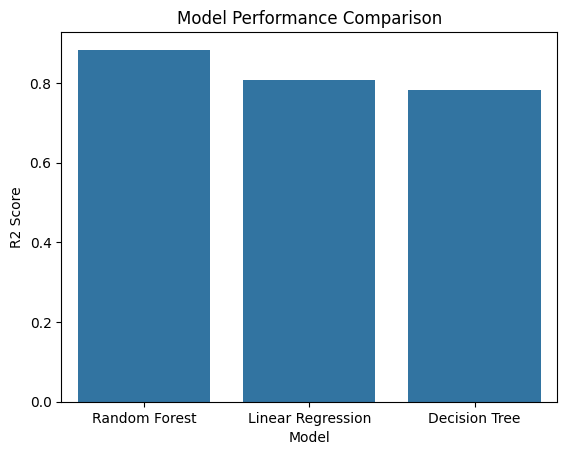

In [36]:
# Model Comparison Graph

sns.barplot(
    x="Model",
    y="R2 Score",
    data=comparison
)

plt.title(
    "Model Performance Comparison"
)

plt.show()

### Observation

Three regression models were evaluated using R² Score.

Random Forest Regressor achieved the highest R² Score and provided the best predictive performance among all models.

Therefore, Random Forest Regressor was selected as the final model for insurance cost prediction.

## Best Model

In [37]:
# Best Model

best_model = comparison.iloc[0]

print(
    f"Best Model: {best_model['Model']} "
    f"with R2 Score = {best_model['R2 Score']:.4f}"
)

Best Model: Random Forest with R2 Score = 0.8834


## Feature importance

In [38]:
# Find  Feature importance


rf_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf_model.feature_importances_
})

rf_importance = rf_importance.sort_values(
    by="Importance",
    ascending=False
)

print(rf_importance)


    Feature  Importance
4    smoker    0.600777
2       bmi    0.216170
0       age    0.136473
3  children    0.023294
5    region    0.016106
1       sex    0.007179


## Feature importance Graph

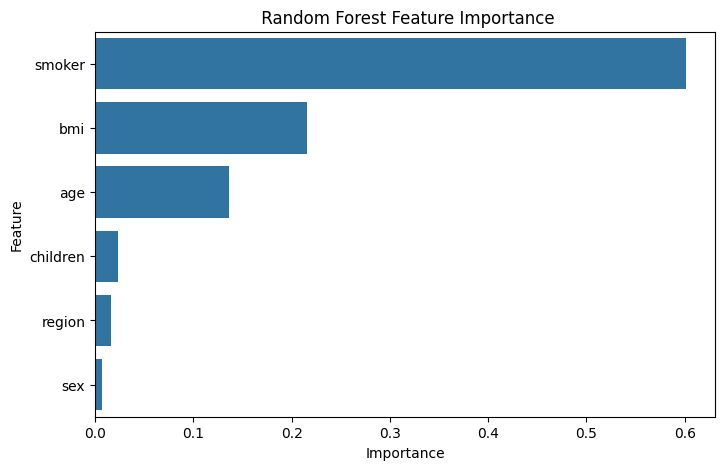

In [39]:
# Feature Importance  Graph

plt.figure(figsize=(8,5))

sns.barplot(
    x="Importance",
    y="Feature",
    data=rf_importance
)

plt.title(" Random Forest Feature Importance")
plt.show()

### Observation

Smoking status is the most important feature affecting insurance charges.

Age and BMI also have a significant impact on insurance costs, while region and number of children contribute comparatively less to the prediction.

The Random Forest model identifies feature importance based on how much each feature helps improve prediction accuracy.

## Save Model

In [40]:
# Save Model

import joblib

joblib.dump(
    rf_model,
    "insurance_model.pkl"
)

print("Model saved successfully!")


Model saved successfully!


##  Prediction 

In [41]:
# Prediction for New Customer

new_customer = pd.DataFrame({
    "age":[25],
    "sex":[1],
    "bmi":[28.5],
    "children":[0],
    "smoker":[0],
    "region":[2],
})

prediction = rf_model.predict(new_customer)

print("Predicted Insurance Cost:", prediction[0])

Predicted Insurance Cost: 2492.8862144999975


# Conclusion - Insurance Cost Prediction


The objective of this project was to predict insurance charges using demographic and health-related features such as age, sex, BMI, number of children, smoking status, and region.

Data cleaning, exploratory data analysis (EDA), feature engineering, and model building were performed successfully.

Three machine learning models were trained and evaluated:

1. Linear Regression
2. Decision Tree Regressor
3. Random Forest Regressor

The models were compared using the R² Score metric. Random Forest Regressor achieved the highest performance and was selected as the final model.

Key Findings:
- Smoking status has the strongest impact on insurance charges.
- Age positively affects insurance costs.
- BMI also influences insurance charges.
- Region and number of children have comparatively smaller effects.

This model can help insurance companies estimate medical insurance costs for new customers and support better decision-making.

In [42]:
import os

print(os.getcwd())

C:\Users\Administrator


In [43]:
import os

print(os.listdir())

['.anaconda', '.bash_history', '.cache', '.conda', '.condarc', '.continuum', '.ipynb_checkpoints', '.ipython', '.jupyter', '.matplotlib', '.vscode', '.vscode-shared', 'anaconda3', 'anaconda_projects', 'AppData', 'Application Data', 'cell phone', 'company python program', 'Contacts', 'Cookies', 'Desktop', 'Documents', 'Downloads', 'Favorites', 'git', 'heart disease predection', 'Insurance Cost Prediction .docx', 'insurance.csv', 'insurance_cost_predicton.ipynb', 'insurance_model.pkl', 'IntelGraphicsProfiles', 'Links', 'Local Settings', 'Microsoft', 'ML  Numpy practice.ipynb', 'ML practice.ipynb', 'model_comparison.csv', 'Music', 'My Documents', 'NetHood', 'New folder', 'New folder (2)', 'New folder (3)', 'New folder (4)', 'NTUSER.DAT', 'ntuser.dat.LOG1', 'ntuser.dat.LOG2', 'NTUSER.DAT{58c33e0f-4233-11f1-a5b9-b92394032976}.TxR.0.regtrans-ms', 'NTUSER.DAT{58c33e0f-4233-11f1-a5b9-b92394032976}.TxR.1.regtrans-ms', 'NTUSER.DAT{58c33e0f-4233-11f1-a5b9-b92394032976}.TxR.2.regtrans-ms', 'NTUSER

In [44]:
import os

print(os.path.abspath("insurance.csv"))
print(os.path.abspath("insurance_cost_predicton.ipynb"))
print(os.path.abspath("insurance_model.pkl"))

C:\Users\Administrator\insurance.csv
C:\Users\Administrator\insurance_cost_predicton.ipynb
C:\Users\Administrator\insurance_model.pkl


In [45]:
import os
import shutil

project_folder = "Insurance-Cost-Prediction"

os.makedirs(project_folder, exist_ok=True)

shutil.copy("insurance.csv", project_folder)
shutil.copy("insurance_cost_predicton.ipynb", project_folder)
shutil.copy("insurance_model.pkl", project_folder)

print("Project folder created successfully!")
print(os.listdir(project_folder))

FileNotFoundError: [Errno 2] No such file or directory: 'insurance_cost_predicton.ipynb'

In [46]:
import os

for file in os.listdir():
    if file.endswith(".ipynb"):
        print(file)

insurance_cost_prediction.ipynb
ML  Numpy practice.ipynb
ML practice.ipynb
NumPy_Arrays_and_Operations_1.ipynb
NumPy_Indexing_and_Selection_2.ipynb
pandas practice.ipynb
Pandas.ipynb
Python Essentials Part_I (2).ipynb
Python Essentials Part_II (1).ipynb
Python Essentials Part_III.ipynb
python practice 2.ipynb
python practice.ipynb
Untitled.ipynb
Untitled1.ipynb
Untitled3.ipynb


In [47]:
import os
import shutil

project_folder = "Insurance-Cost-Prediction"

os.makedirs(project_folder, exist_ok=True)

shutil.copy("insurance.csv", project_folder)
shutil.copy("insurance_cost_prediction.ipynb", project_folder)
shutil.copy("insurance_model.pkl", project_folder)
shutil.copy("model_comparison.csv", project_folder)

print("Files copied successfully!")
print(os.listdir(project_folder))

Files copied successfully!
['insurance.csv', 'insurance_cost_prediction.ipynb', 'insurance_model.pkl', 'model_comparison.csv']


In [48]:
import os

print(os.path.abspath("Insurance-Cost-Prediction"))

C:\Users\Administrator\Insurance-Cost-Prediction


In [49]:
import os

for file in os.listdir():
    if file.endswith(".ipynb"):
        print(file)

insurance_cost_prediction.ipynb
ML  Numpy practice.ipynb
ML practice.ipynb
NumPy_Arrays_and_Operations_1.ipynb
NumPy_Indexing_and_Selection_2.ipynb
pandas practice.ipynb
Pandas.ipynb
Python Essentials Part_I (2).ipynb
Python Essentials Part_II (1).ipynb
Python Essentials Part_III.ipynb
python practice 2.ipynb
python practice.ipynb
Untitled.ipynb
Untitled1.ipynb
Untitled3.ipynb


In [50]:
import os

print(os.getcwd())
print(os.listdir())

C:\Users\Administrator
['.anaconda', '.bash_history', '.cache', '.conda', '.condarc', '.continuum', '.ipynb_checkpoints', '.ipython', '.jupyter', '.matplotlib', '.vscode', '.vscode-shared', 'anaconda3', 'anaconda_projects', 'AppData', 'Application Data', 'cell phone', 'company python program', 'Contacts', 'Cookies', 'Desktop', 'Documents', 'Downloads', 'Favorites', 'git', 'heart disease predection', 'Insurance Cost Prediction .docx', 'Insurance-Cost-Prediction', 'insurance.csv', 'insurance_cost_prediction.ipynb', 'insurance_model.pkl', 'IntelGraphicsProfiles', 'Links', 'Local Settings', 'Microsoft', 'ML  Numpy practice.ipynb', 'ML practice.ipynb', 'model_comparison.csv', 'Music', 'My Documents', 'NetHood', 'New folder', 'New folder (2)', 'New folder (3)', 'New folder (4)', 'NTUSER.DAT', 'ntuser.dat.LOG1', 'ntuser.dat.LOG2', 'NTUSER.DAT{58c33e0f-4233-11f1-a5b9-b92394032976}.TxR.0.regtrans-ms', 'NTUSER.DAT{58c33e0f-4233-11f1-a5b9-b92394032976}.TxR.1.regtrans-ms', 'NTUSER.DAT{58c33e0f-423

In [51]:
import os

os.startfile(r"C:\Users\Administrator")

In [52]:
import os

print(os.path.exists("insurance.csv"))
print(os.path.exists("insurance_cost_prediction.ipynb"))
print(os.path.exists("insurance_model.pkl"))

True
True
True
